In [ ]:
!pip install "numpy==1.26.4"
!pip install "pmdarima==2.0.4"

# Aprendizaje Automático (clase 3)

## Diego Fernando Agudelo - Daniel Felipe Osorio
## Universidad ICESI
## diegoagudelo30@gmail.com - dfosorio@icesi.edu.co

In [3]:
import numpy as np
# matplotlib=3.8.4

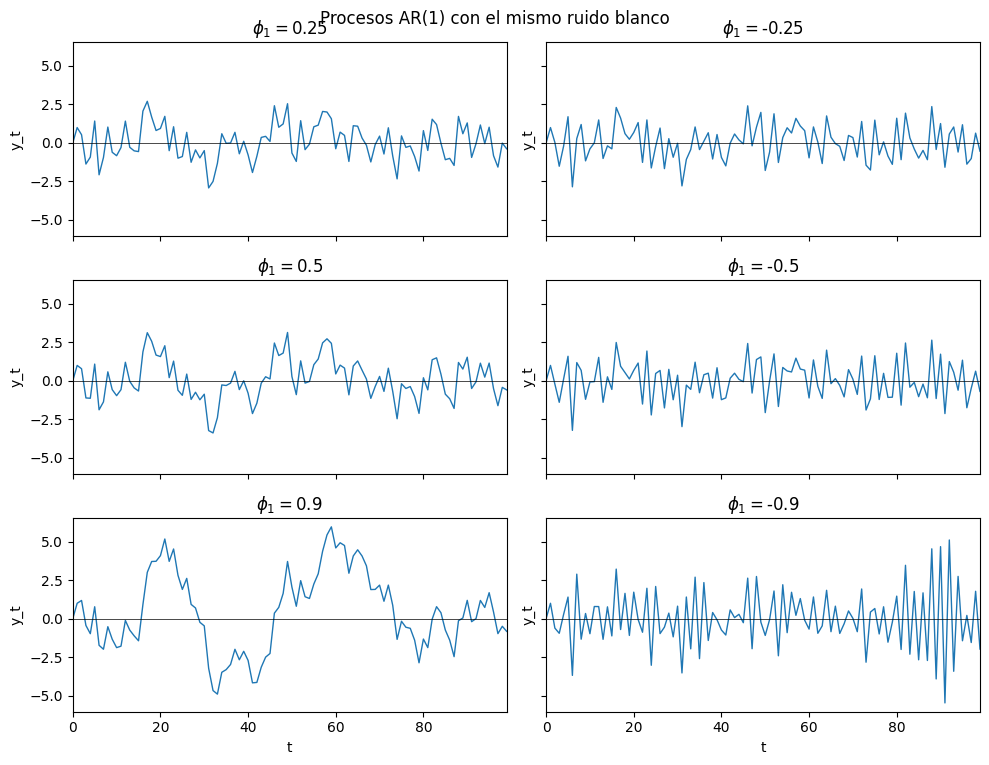

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibilidad
np.random.seed(123)

T = 100               # número de observaciones
phis = [0.25, -0.25, 0.5, -0.5, 0.9, -0.9]
sigma_eps = 1         # desviación estándar del ruido
eps = np.random.normal(0, sigma_eps, T)   # mismos eps para todos

def sim_ar1(phi, eps):
    y = np.zeros_like(eps)
    for t in range(1, len(eps)):
        y[t] = phi * y[t-1] + eps[t]
    return y

series = [sim_ar1(phi, eps) for phi in phis]

# graficar
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, (phi, y) in enumerate(zip(phis, series)):
    axes[i].plot(y, linewidth=1)
    axes[i].set_title(r"$\phi_1 = $" + f"{phi}")
    axes[i].set_xlim(0, T-1)
    axes[i].axhline(0, color='black', linewidth=0.5)
    if i >= 4:  # últimas filas muestran eje x
        axes[i].set_xlabel("t")
    axes[i].set_ylabel("y_t")

plt.suptitle("Procesos AR(1) con el mismo ruido blanco", y=0.95)
plt.tight_layout()
plt.show()

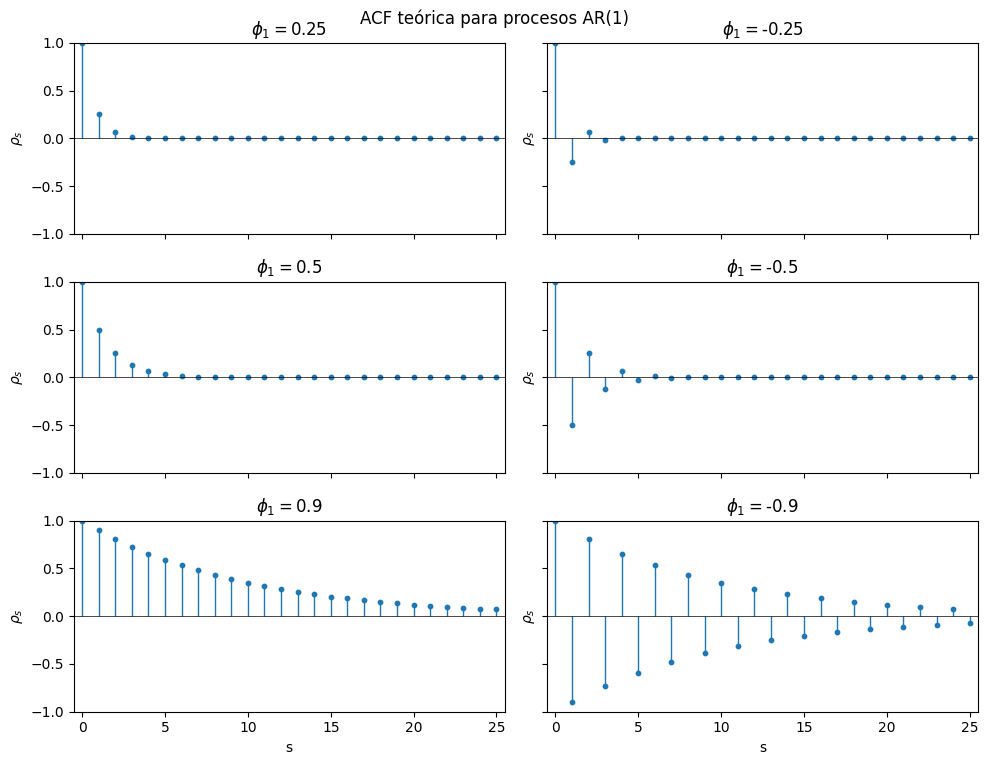

In [5]:
max_lag = 25

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, phi in enumerate(phis):
    lags = np.arange(0, max_lag + 1)
    acf = phi ** lags   # rho_s = phi^s

    ax = axes[i]
    # dibujar como palitos
    ax.vlines(lags, 0, acf, linewidth=1)
    ax.scatter(lags, acf, s=10)

    ax.set_title(r"$\phi_1 = $" + f"{phi}")
    ax.set_xlim(-0.5, max_lag + 0.5)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color="black", linewidth=0.5)

    if i >= 4:
        ax.set_xlabel("s")
    ax.set_ylabel(r"$\rho_s$")

plt.suptitle("ACF teórica para procesos AR(1)", y=0.95)
plt.tight_layout()
plt.show()

## **1. Carga de paquetes**

In [6]:
#!pip install pmdarima
from pmdarima.arima import auto_arima
from pmdarima.utils import acf,pacf
from pmdarima.arima import ARIMA
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from matplotlib import pyplot as plt # gráficos
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

import warnings
warnings.filterwarnings("ignore")

## **2. Carga de datos**

Vamos a usar unos datos simulados de un proceso ARIMA(0,1,1)

In [18]:
data = pd.read_csv("https://raw.githubusercontent.com/profedaniel86/Series_de_Tiempo/refs/heads/main/3.%20ARIMA/arima011.csv")
data.head()

,time,ARIMA011
0,1,0.000000
1,2,1.177889
2,3,1.636159
3,4,1.095219
4,5,1.338308


## **3. ACF y PACF**

In [19]:
acf(data['ARIMA011'],40)

array([ 1.        ,  0.97067998,  0.936947  ,  0.90268173,  0.87006769,
        0.83930648,  0.80550412,  0.76900548,  0.729861  ,  0.69187304,
        0.65491402,  0.61463437,  0.5742899 ,  0.53486342,  0.4947723 ,
        0.45508868,  0.4193302 ,  0.38735224,  0.35741482,  0.3287006 ,
        0.29967955,  0.27332986,  0.25145635,  0.23117776,  0.20756429,
        0.18071305,  0.15605784,  0.1350231 ,  0.11849087,  0.10466391,
        0.08840871,  0.07087046,  0.05395363,  0.0389593 ,  0.02929347,
        0.02384452,  0.01739524,  0.00720187, -0.00414497, -0.0120686 ,
       -0.01886248])

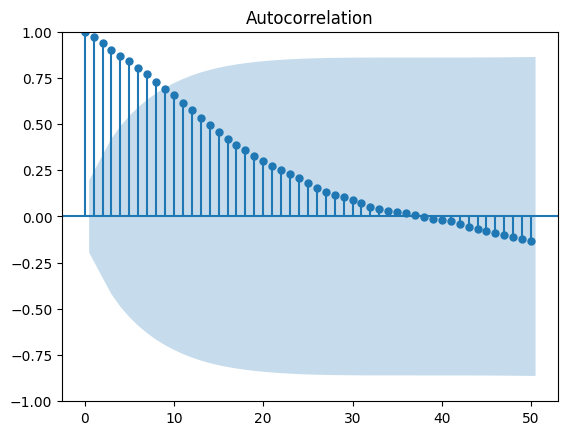

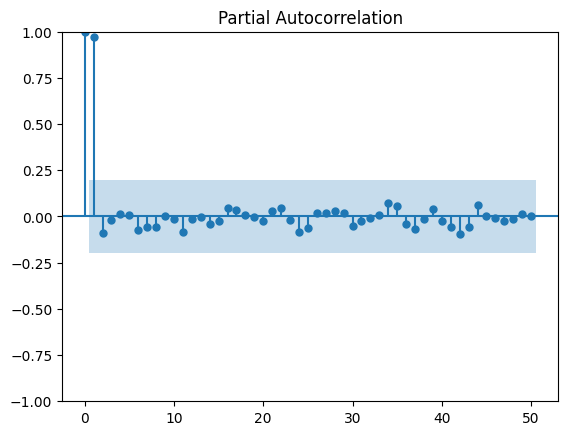

In [20]:
plot_acf(data['ARIMA011'],lags=50);
plot_pacf(data['ARIMA011'],lags=50);

In [21]:
data.shape

(101, 2)

In [10]:
## information_criterion (‘aic’, ‘aicc’, ‘bic’, ‘hqic’, ‘oob’)
model = auto_arima(data["ARIMA011"],max_p=10, max_q=10,information_criterion = ("aic"),trace=True,error_action='ignore',suppress_warnings=True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=355.502, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=337.330, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=310.695, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=362.792, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=311.703, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=311.629, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=313.142, Time=0.04 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.257 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  101
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -152.348
Date:                Tue, 11 Nov 2025   AIC                            310.695
Time:                        18:51:48   BIC                            318.511
Sample:                             0   HQIC                           313.858
                                - 101                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4366      0.207      2.105      0.035       0.030       0.843
ma.L1          0.8592      0.062     13.960      0.000       0.739       0.980
sigma2         1.2161      0.200      6.077      0.000       0.824       1.608
===================================================================================
Ljung-Box (L1) (Q):                   0.52   Jarque-Bera (JB):                 1.40
Prob(Q):                              0.47   Prob(JB):                         0.50
Heteroskedasticity (H):               1.04   Skew:                            -0.16
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
model = auto_arima(data["ARIMA011"],max_p=10, max_q=10,information_criterion = ("bic"),trace=True,error_action='ignore',suppress_warnings=True)
model.summary()

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : BIC=inf, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=360.712, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=345.146, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=318.511, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=365.397, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=322.124, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : BIC=322.050, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : BIC=inf, Time=0.32 sec
 ARIMA(0,1,1)(0,0,0)[0]             : BIC=318.353, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : BIC=322.679, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : BIC=322.699, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : BIC=344.116, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : BIC=inf, Time=0.29 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.447 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  101
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -154.571
Date:                Tue, 11 Nov 2025   AIC                            313.142
Time:                        18:51:53   BIC                            318.353
Sample:                             0   HQIC                           315.251
                                - 101                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.8706      0.058     15.050      0.000       0.757       0.984
sigma2         1.2704      0.212      5.986      0.000       0.854       1.686
===================================================================================
Ljung-Box (L1) (Q):                   0.67   Jarque-Bera (JB):                 1.40
Prob(Q):                              0.41   Prob(JB):                         0.50
Heteroskedasticity (H):               1.07   Skew:                            -0.17
Prob(H) (two-sided):                  0.84   Kurtosis:                         2.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
model.resid()

0      0.000000
1      1.177889
2     -0.125066
3     -0.458875
4      0.579740
         ...   
96    -0.552438
97     2.234642
98    -0.819120
99    -0.461252
100    0.069858
Length: 101, dtype: float64

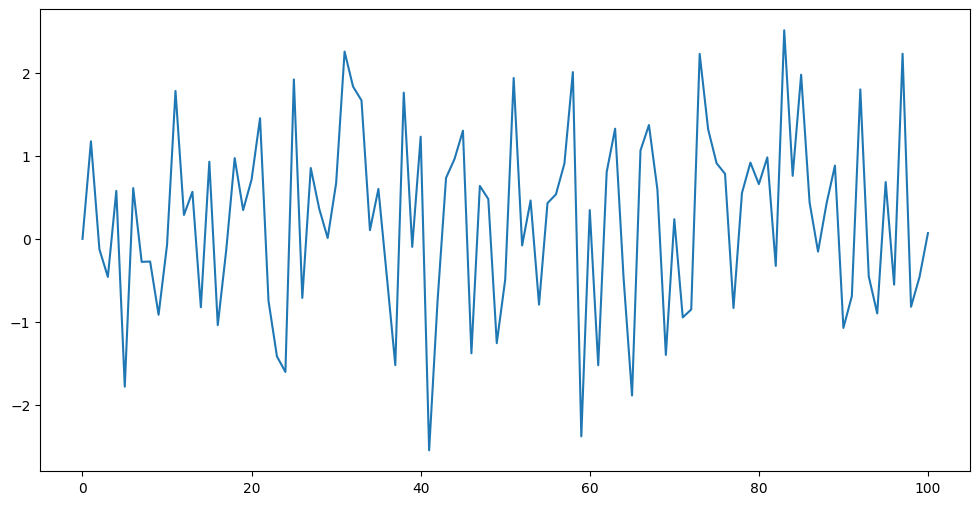

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(model.resid(),label="Residuales")

## **4. Pronóstico del ARIMA(0,1,1) obtenido en el auto.arima**


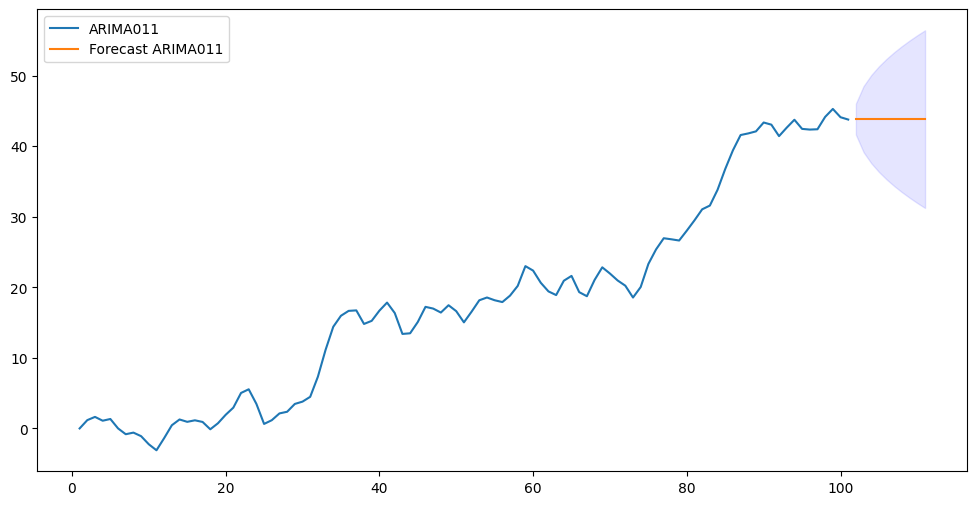

In [14]:
h=10

y_forec, conf_int  = model.predict(h,return_conf_int=True,alpha=0.05)
preds = pd.DataFrame(np.column_stack([y_forec,conf_int[:,0] , conf_int[:,1]]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']

x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)

fig = plt.figure(figsize=(12, 6))
plt.plot(data["time"],data["ARIMA011"],label="ARIMA011")
plt.plot(x_for,preds['Point_forecast'],label="Forecast ARIMA011")
plt.fill_between(x_for,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()


## **5. Replicando el modelo sin hacer auto arima**

In [15]:
model = ARIMA(order=(0,1,1))
results = model.fit( data["ARIMA011"])
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  101
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -152.348
Date:                Tue, 11 Nov 2025   AIC                            310.695
Time:                        18:52:17   BIC                            318.511
Sample:                             0   HQIC                           313.858
                                - 101                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4366      0.207      2.105      0.035       0.030       0.843
ma.L1          0.8592      0.062     13.960      0.000       0.739       0.980
sigma2         1.2161      0.200      6.077      0.000       0.824       1.608
===================================================================================
Ljung-Box (L1) (Q):                   0.52   Jarque-Bera (JB):                 1.40
Prob(Q):                              0.47   Prob(JB):                         0.50
Heteroskedasticity (H):               1.04   Skew:                            -0.16
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## **6. Intervalos de confianza usando boostrap**


In [16]:
h= 10
res = results.resid()

my_samples = []
for _ in range(1000):

    x = np.random.choice(res, size=h, replace=True)
    my_samples.append(x)

q1=np.quantile(my_samples,0.025,axis=0)
q2=np.quantile(my_samples,0.975,axis=0)

fore = results.predict(h,return_conf_int=False)

preds = pd.DataFrame(np.column_stack([fore,fore+np.cumsum(q1) , fore+np.cumsum(q2)]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']

preds


,Point_forecast,lower_95,upper_95
0,44.095552,41.985087,46.118440
1,44.532142,40.311213,48.561290
2,44.968731,38.702677,51.020768
3,45.405321,37.028802,53.463618
4,45.841911,35.354927,55.906468
5,46.278501,33.746391,58.327769
6,46.715090,31.565361,60.771034
7,47.151680,29.891486,63.213884
8,47.588270,28.217611,65.656734
9,48.024860,26.543737,68.099585


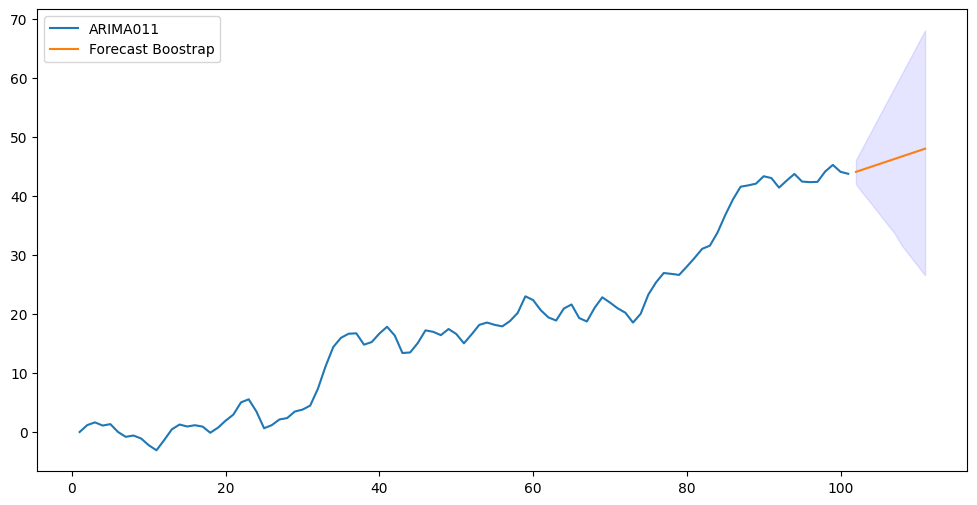

In [17]:
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)

fig = plt.figure(figsize=(12, 6))
plt.plot(data["time"],data["ARIMA011"],label="ARIMA011")
plt.plot(x_for,preds['Point_forecast'],label="Forecast Boostrap")
plt.fill_between(x_for,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **7. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses empleando los métodos vistos en la clase. Compare
los resultados con el mejor modelo encontrado en el ejercicio anterior.

Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.